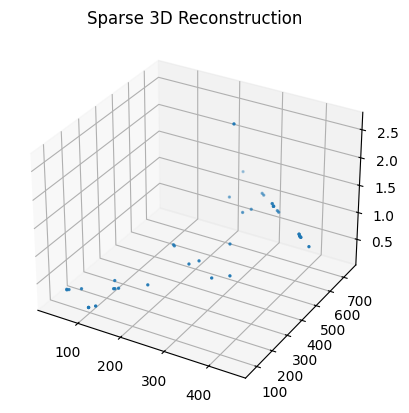

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Paths to two consecutive images in your dataset
img_path1 = 'Datasets/dataset_flowerpot-master/full_dataset/P81019-151014.jpg'
img_path2 = 'Datasets/dataset_flowerpot-master/full_dataset/P81019-151035.jpg'

# Load images and convert to grayscale
img1 = cv2.imread(img_path1)
img2 = cv2.imread(img_path2)
gray1 = cv2.cvtColor(img1, cv2.COLOR_BGR2GRAY)
gray2 = cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY)

# Resize for speed (optional)
scale_percent = 20
resize = lambda img: cv2.resize(img, (int(img.shape[1]*scale_percent/100), int(img.shape[0]*scale_percent/100)))
gray1 = resize(gray1)
gray2 = resize(gray2)

# Detect SIFT keypoints and descriptors
sift = cv2.SIFT_create()
kp1, des1 = sift.detectAndCompute(gray1, None)
kp2, des2 = sift.detectAndCompute(gray2, None)

# Match descriptors with BFMatcher and apply Lowe's ratio test
bf = cv2.BFMatcher()
matches = bf.knnMatch(des1, des2, k=2)
good_matches = [m for m, n in matches if m.distance < 0.75 * n.distance]

# Extract point coordinates
pts1 = np.float32([kp1[m.queryIdx].pt for m in good_matches])
pts2 = np.float32([kp2[m.trainIdx].pt for m in good_matches])

# Estimate Fundamental Matrix with RANSAC
F, mask = cv2.findFundamentalMat(pts1, pts2, cv2.FM_RANSAC)

# Keep only inlier matches
pts1 = pts1[mask.ravel() == 1]
pts2 = pts2[mask.ravel() == 1]

# Construct camera matrices P1 and P2 (projective cameras)
P1 = np.hstack((np.eye(3), np.zeros((3, 1))))  # [I | 0]

# Compute epipole and P2 from F using SVD
U, S, Vt = np.linalg.svd(F)
e = Vt[-1]
e = e / e[2]
ex = np.array([[0, -e[2], e[1]],
               [e[2], 0, -e[0]],
               [-e[1], e[0], 0]])
P2 = np.hstack((ex @ F, e.reshape(3, 1)))

# Triangulate points
pts1_h = cv2.convertPointsToHomogeneous(pts1)[:, 0, :]
pts2_h = cv2.convertPointsToHomogeneous(pts2)[:, 0, :]
pts_4d = cv2.triangulatePoints(P1, P2, pts1.T[:2], pts2.T[:2])

# Convert from homogeneous coordinates to 3D
pts_3d = pts_4d[:3] / pts_4d[3]

# Plot 3D points
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(pts_3d[0], pts_3d[1], pts_3d[2], s=2)
ax.set_title('Sparse 3D Reconstruction')
plt.show()
